<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/20_regularization/20_1_Practical_Training/20_1_5_Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularization: Part 5
## The Full Regularized Pipeline
---

## What This Notebook Is About

This is the capstone of the module. Over the last four notebooks you collected four practical training tools:

- **Dropout** (20_1_1) — fights overfitting by randomly zeroing activations
- **Batch normalization** (20_1_2) — stabilizes training and tolerates larger learning rates
- **Learning rate schedules** (20_1_3) — large steps early, small steps late
- **Early stopping with checkpointing** (20_1_4) — capture the best epoch, stop when it stops improving

Here we assemble all four into one reusable `train_model()` function — the template you can lift into your own projects — and then ask an honest question: *how much does each technique actually help?* The answer depends entirely on the problem. We will see one dataset where regularization clearly rescues an overfitting model, and another where the plain network is already so good that regularization barely moves the needle. Knowing which situation you are in is the real skill.

**What you will learn:**
1. How to write the standard regularized block as a reusable, parameterized builder
2. How to write one `train_model()` function that bundles scheduling + early stopping + checkpointing
3. When regularization helps a lot (an overfitting model) versus barely at all (an already-strong baseline)
4. How to read a final training report: best epoch, test performance, parameter count

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
from sklearn.utils import compute_class_weight
import tempfile, os

import seaborn as sns
sns.set_theme(style='whitegrid')
torch.manual_seed(42)

# Production-template dataset: CTG fetal health (same as 19_1_3, 3 classes)
data_ctg = fetch_openml(name='cardiotocography', version=2, as_frame=True, parser='auto')
df = data_ctg.frame.copy()
class_names = ['Normal', 'Suspect', 'Pathological']
df['Class'] = df['Class'].astype(str).map({'1': 0, '2': 1, '3': 2})
df = df.dropna().reset_index(drop=True)

X_raw = df.drop(columns=['Class']).to_numpy(dtype=np.float32)
y_raw = df['Class'].to_numpy(dtype=np.int64)

X_tmp, X_test_np, y_tmp, y_test_np = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=42
)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=42
)
scaler     = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_val_np   = scaler.transform(X_val_np)
X_test_np  = scaler.transform(X_test_np)

X_train = torch.tensor(X_train_np); y_train = torch.tensor(y_train_np)
X_val   = torch.tensor(X_val_np);   y_val   = torch.tensor(y_val_np)
X_test  = torch.tensor(X_test_np);  y_test  = torch.tensor(y_test_np)

N_FEATURES = X_train.shape[1]
BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)

# Balanced class weights (CTG is imbalanced; same approach as 19_1_3)
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.arange(3), y=y_train_np),
    dtype=torch.float32
)

print(f'CTG: {X_raw.shape[0]} samples, {N_FEATURES} features, 3 classes')
print(f'Train {X_train.shape[0]}  Val {X_val.shape[0]}  Test {X_test.shape[0]}')
print('Class counts:', np.bincount(y_raw).tolist(), '(imbalanced -> balanced loss weights)')

CTG: 2126 samples, 35 features, 3 classes
Train 1275  Val 425  Test 426
Class counts: [1655, 295, 176] (imbalanced -> balanced loss weights)


---

## Section 1: The Regularized Architecture

In 20_1_2 we settled on the standard regularized block: `Linear → BatchNorm → ReLU → Dropout`. The builder below stacks that block to any depth, with switches to turn batch norm and dropout on or off. Those switches are what make the ablation in Section 3 possible — we can build the *same* network with and without each technique and compare fairly.

In [2]:
def build_net(n_features, n_classes, hidden=(128, 64),
              use_bn=False, use_dropout=False, dropout_p=0.3):
    """Stack `Linear -> [BatchNorm] -> ReLU -> [Dropout]` blocks.

    use_bn / use_dropout toggle each technique so we can ablate them.
    Returns raw logits (no softmax) for use with CrossEntropyLoss."""
    layers = []
    in_dim = n_features
    for width in hidden:
        layers.append(nn.Linear(in_dim, width))
        if use_bn:
            layers.append(nn.BatchNorm1d(width))
        layers.append(nn.ReLU())
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))
        in_dim = width
    layers.append(nn.Linear(in_dim, n_classes))   # logits
    return nn.Sequential(*layers)


# The fully-regularized version, for inspection
torch.manual_seed(42)
demo = build_net(N_FEATURES, 3, use_bn=True, use_dropout=True)
print(demo)
print(f'\nParameters: {sum(p.numel() for p in demo.parameters()):,}')

Sequential(
  (0): Linear(in_features=35, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=64, out_features=3, bias=True)
)

Parameters: 13,443


---

## Section 2: The Complete `train_model()` Function

This single function is the deliverable of the whole module. It runs the canonical training loop and folds in three of the four techniques (dropout and batch norm live in the *model*, so they are already handled by `build_net`):

- an optional **learning rate scheduler**, stepped once per epoch after the optimizer;
- **checkpointing** — save the model whenever validation loss reaches a new low;
- **early stopping** — halt after `patience` epochs with no improvement, then restore the best checkpoint.

It returns the trained model (restored to its best epoch) plus the loss history, so we can plot and compare runs. This is the template to reuse in your own projects.

In [3]:
def train_model(model, optimizer, criterion, train_loader, X_val, y_val,
                max_epochs=150, scheduler=None, patience=None, quiet=True):
    """Train with checkpointing + optional scheduler and early stopping.

    Saves the best-val-loss weights to a temp file and restores them at the end.
    Returns (model, history) where history has train/val loss and bookkeeping."""
    ckpt_path = os.path.join(tempfile.mkdtemp(), 'best.pt')
    best_val, best_epoch, patience_counter = float('inf'), -1, 0
    stopped_at = max_epochs - 1
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        running = 0.0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            running += loss.item()
        train_losses.append(running / len(train_loader))

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()
        val_losses.append(val_loss)

        if val_loss < best_val:                      # checkpoint the new best
            best_val, best_epoch, patience_counter = val_loss, epoch, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_counter += 1

        if patience is not None and patience_counter >= patience:
            stopped_at = epoch
            if not quiet:
                print(f'  early stop at epoch {epoch} (best was epoch {best_epoch})')
            break

        if scheduler is not None:
            scheduler.step()                         # after optimizer, once per epoch

    model.load_state_dict(torch.load(ckpt_path, weights_only=True))   # restore best
    return model, {'train': train_losses, 'val': val_losses,
                   'best_epoch': best_epoch, 'best_val': best_val,
                   'stopped_at': stopped_at}

---

## Section 3: When Regularization Rescues a Model

Regularization earns its keep when a model is *overfitting* — and the clearest example in this module is the oversized (256, 256) network on the breast-cancer data from 20_1_1, whose validation loss bottomed out early and then climbed. Let's load that binary dataset and train it two ways with our new template: a plain baseline, and a fully-regularized version (BatchNorm + dropout + cosine schedule + early stopping).

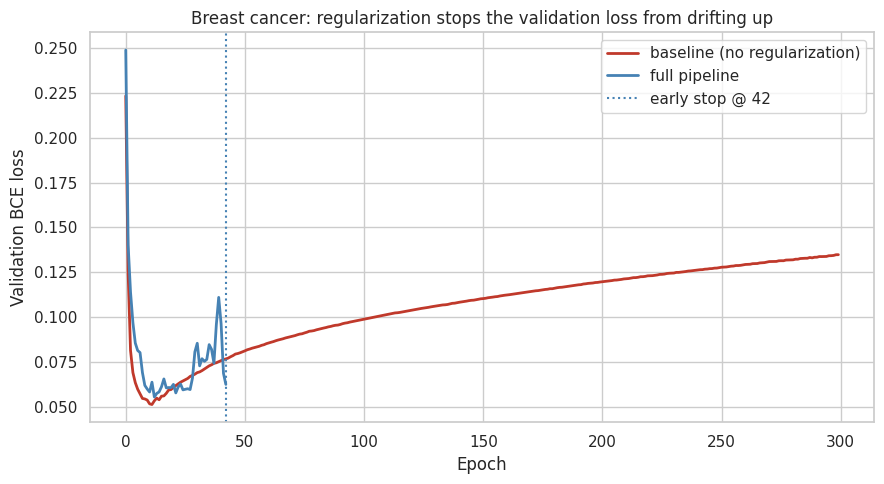

                  best val    end-of-training val
baseline      :    0.0513         0.1348   (ran all 300 epochs)
full pipeline :    0.0555         0.0625   (early-stopped @ 42)


In [4]:
# Breast-cancer data (binary) — the overfitting showcase from 20_1_1
bc = load_breast_cancer()
Xb, yb = bc.data.astype(np.float32), bc.target.astype(np.float32)
Xb_tmp, Xb_te, yb_tmp, yb_te = train_test_split(Xb, yb, test_size=0.20, stratify=yb, random_state=42)
Xb_tr, Xb_va, yb_tr, yb_va = train_test_split(Xb_tmp, yb_tmp, test_size=0.25, stratify=yb_tmp, random_state=42)
bsc = StandardScaler()
Xb_tr = torch.tensor(bsc.fit_transform(Xb_tr)); Xb_va = torch.tensor(bsc.transform(Xb_va)); Xb_te = torch.tensor(bsc.transform(Xb_te))
yb_tr = torch.tensor(yb_tr).unsqueeze(1); yb_va = torch.tensor(yb_va).unsqueeze(1); yb_te = torch.tensor(yb_te).unsqueeze(1)
bc_loader = DataLoader(TensorDataset(Xb_tr, yb_tr), batch_size=32, shuffle=True)


def bc_net(regularized):
    torch.manual_seed(42)
    if regularized:
        return nn.Sequential(
            nn.Linear(30, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 1), nn.Sigmoid())
    return nn.Sequential(
        nn.Linear(30, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 1), nn.Sigmoid())


# Baseline: plain network, no schedule, no early stopping (runs all 300 epochs)
base = bc_net(False)
base_model, base_hist = train_model(
    base, torch.optim.Adam(base.parameters(), lr=1e-3),
    nn.BCELoss(), bc_loader, Xb_va, yb_va, max_epochs=300)

# Full pipeline: BatchNorm + dropout + cosine schedule + early stopping
reg = bc_net(True)
reg_opt = torch.optim.Adam(reg.parameters(), lr=1e-3)
reg_model, reg_hist = train_model(
    reg, reg_opt, nn.BCELoss(), bc_loader, Xb_va, yb_va, max_epochs=300,
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(reg_opt, T_max=300),
    patience=30)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(base_hist['val'], color='#C0392B',   lw=2, label='baseline (no regularization)')
ax.plot(reg_hist['val'],  color='steelblue', lw=2, label='full pipeline')
ax.axvline(reg_hist['stopped_at'], color='steelblue', ls=':', lw=1.5,
           label=f"early stop @ {reg_hist['stopped_at']}")
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation BCE loss')
ax.set_title('Breast cancer: regularization stops the validation loss from drifting up')
ax.legend()
plt.tight_layout(); plt.show()

print('                  best val    end-of-training val')
print(f'baseline      :    {base_hist["best_val"]:.4f}         {base_hist["val"][-1]:.4f}   (ran all 300 epochs)')
print(f'full pipeline :    {reg_hist["best_val"]:.4f}         {reg_hist["val"][-1]:.4f}   (early-stopped @ {reg_hist["stopped_at"]})')

This is the dropout story from 20_1_1, now with the whole toolkit and the precise mechanism on display:

- **The baseline drifts.** Its best validation loss is excellent and comes early (around epoch 11), but with nothing to stop it the loss then climbs steadily — by epoch 300 it is roughly **three times** its best value. The plain model is overfitting hard in its late epochs.
- **The full pipeline never gets the chance to drift.** Early stopping halts the run around epoch 40 — `patience` epochs past the best — so its endpoint is still near the best value, while batch norm and dropout damp how fast the loss climbs inside that window. (As 20_1_1 showed, dropout alone cannot stop this oversized network from eventually memorizing; the *stopping* is what protects the endpoint, and the regularizers buy it a gentler window to stop in.)

A subtle but important point about the *test* numbers below: because `train_model` restores the best checkpoint, the baseline is evaluated at its epoch-11 weights, not its drifted endpoint — so on the test set the two models land close together. In other words, **the baseline needs checkpointing to rescue it from its own late drift; the full-pipeline model is good all the way to its endpoint.** Regularization did not find a lower floor here (it rarely does); what it bought is a model you can train without babysitting.

In [5]:
for name, model, Xv_, yv_ in [('baseline', base_model, Xb_te, yb_te),
                              ('full pipeline', reg_model, Xb_te, yb_te)]:
    model.eval()
    with torch.no_grad():
        preds = (model(Xv_) > 0.5).long().squeeze().numpy()
    acc = (preds == yv_.long().squeeze().numpy()).mean()
    print(f'{name:14}  test accuracy (best checkpoint restored): {acc:.3f}')

baseline        test accuracy (best checkpoint restored): 0.956
full pipeline   test accuracy (best checkpoint restored): 0.965


---

## Section 4: When the Baseline Is Already Excellent

Now the honest counterpoint. Not every problem is overfitting, and on those problems regularization has little to add. The CTG dataset is one such case — back in 19_1_3 a plain `CTGNet` already reached about 0.98 macro F1.

We run a clean **ablation** on CTG: the same architecture trained four ways — baseline, +dropout, +batchnorm, +both — each for a fixed 150 epochs with checkpointing (no schedule, no early stopping, so the *only* thing changing is which regularizers are on). We read the test macro F1 of each.

In [6]:
configs = [
    ('baseline',    dict(use_bn=False, use_dropout=False)),
    ('+ dropout',   dict(use_bn=False, use_dropout=True)),
    ('+ batchnorm', dict(use_bn=True,  use_dropout=False)),
    ('+ both',      dict(use_bn=True,  use_dropout=True)),
]

print('CTG ablation — same net, 150 epochs, checkpoint-restored, one variable at a time:\n')
print(f'{"config":<14}{"test macro F1":>14}{"best epoch":>12}')
results = {}
for name, kw in configs:
    torch.manual_seed(42)
    net = build_net(N_FEATURES, 3, **kw)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
    net, hist = train_model(net, opt, nn.CrossEntropyLoss(weight=class_weights),
                            train_loader, X_val, y_val, max_epochs=150)
    net.eval()
    with torch.no_grad():
        preds = net(X_test).argmax(dim=1).numpy()
    f1 = f1_score(y_test_np, preds, average='macro')
    results[name] = f1
    print(f'{name:<14}{f1:>14.3f}{hist["best_epoch"]:>12}')

print(f'\nSpread across all four configs: {max(results.values()) - min(results.values()):.3f} macro F1')

CTG ablation — same net, 150 epochs, checkpoint-restored, one variable at a time:

config         test macro F1  best epoch


baseline               0.983          68


+ dropout              0.978         117


+ batchnorm            0.983         123


+ both                 0.978         135

Spread across all four configs: 0.005 macro F1


The four numbers are essentially the same — they differ by less than the noise of a single train/test split. On CTG, the plain network is **not** overfitting, so there is nothing for dropout or batch norm to fix; adding them neither helps nor meaningfully hurts. This is the lesson the breast-cancer showcase sets up by contrast: **regularization is a fix for overfitting, not a free upgrade.** When the baseline already generalizes well, the regularizers are along for the ride.

Why bother with the full pipeline on a dataset like this, then? Because you usually do not *know* in advance whether you are in the breast-cancer situation or the CTG situation — and the regularized pipeline is safe in both. It rescues you when you are overfitting and costs you almost nothing when you are not. That is what makes it a sensible default.

---

## Section 5: The Final Training Report

To close, we train the full production pipeline on CTG — the regularized architecture, a cosine schedule, and early stopping — on the combined train+validation data, and report the things you would record for any trained model: where the best epoch landed, the test performance, and the model size.

In [7]:
# Early stopping needs a held-out signal, so we keep the train/val split for monitoring
# and report on the untouched test set (rather than folding val into training here).
torch.manual_seed(42)
final = build_net(N_FEATURES, 3, use_bn=True, use_dropout=True)
final_opt = torch.optim.Adam(final.parameters(), lr=1e-3, weight_decay=1e-4)
final, fhist = train_model(
    final, final_opt, nn.CrossEntropyLoss(weight=class_weights),
    train_loader, X_val, y_val, max_epochs=150,
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(final_opt, T_max=150),
    patience=25)

final.eval()
with torch.no_grad():
    test_preds = final(X_test).argmax(dim=1).numpy()

print('=== Final Training Report: full regularized pipeline on CTG ===\n')
print(f'Architecture     : (128, 64) hidden, BatchNorm + Dropout(0.3)')
print(f'Parameters       : {sum(p.numel() for p in final.parameters()):,}')
print(f'Best epoch       : {fhist["best_epoch"]}  (val loss {fhist["best_val"]:.4f})')
print(f'Stopped at epoch : {fhist["stopped_at"]}')
print(f'Test macro F1    : {f1_score(y_test_np, test_preds, average="macro"):.3f}')
print()
print(classification_report(y_test_np, test_preds, target_names=class_names, digits=3))

=== Final Training Report: full regularized pipeline on CTG ===

Architecture     : (128, 64) hidden, BatchNorm + Dropout(0.3)
Parameters       : 13,443
Best epoch       : 124  (val loss 0.0018)
Stopped at epoch : 149
Test macro F1    : 0.978

              precision    recall  f1-score   support

      Normal      0.988     0.994     0.991       332
     Suspect      0.982     0.932     0.957        59
Pathological      0.972     1.000     0.986        35

    accuracy                          0.986       426
   macro avg      0.981     0.975     0.978       426
weighted avg      0.986     0.986     0.986       426



---

## Putting It All Together

| Piece | Role in the pipeline |
|---|---|
| `build_net(..., use_bn, use_dropout)` | Stacks `Linear → BatchNorm → ReLU → Dropout` blocks; switches enable the ablation |
| `train_model(...)` | One reusable loop: training + checkpointing + optional scheduler + early stopping |
| Dropout + BatchNorm | Live in the model; fight overfitting and stabilize training |
| Cosine schedule | Large steps early, small steps late, stepped once per epoch |
| Early stopping + restore | Halt when val loss stalls; load the best checkpoint, not the last epoch |
| When it helps most | An overfitting model (breast cancer): regularization stops the late drift |
| When it helps least | An already-strong baseline (CTG): the spread across configs is within noise |

**The judgment to take away:** the regularized pipeline is a safe default because it rescues you when you are overfitting and costs almost nothing when you are not — but it is *not* a magic upgrade. Always check whether your baseline is actually overfitting before crediting regularization for an improvement; on many problems the honest finding is "it made no difference," and that is useful to know.

**What is coming next:** Notebook 20_1_9 is the exercise — you will take the toolkit to the Wine Quality dataset you met in 19_1_9 and decide for yourself whether regularization helps a neural network compete with XGBoost on a small, noisy problem.